In [2]:
####   Libraries  ####

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.autograd import Variable
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data.sampler import SubsetRandomSampler

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from typing import Optional, Callable, Union, Iterable, List, Any, Dict, Tuple
from torch import Tensor
from torch.optim.optimizer import Optimizer
import torchvision.transforms.functional as TF
import random
from torchmetrics import StructuralSimilarityIndexMeasure
from torchmetrics import PeakSignalNoiseRatio

import cv2
import glob
import requests
import zipfile
from pathlib import Path
import os


import pathlib
import scipy.io
from PIL import Image
from numpy import asarray, newaxis
!pip install piqa
from piqa import SSIM, PSNR


#print("PyTorch Version: ",torch.__version__)   # Be sure about having pytorch properly!
#print("Torchvision Version: ",torchvision.__version__)f the current session

In [3]:
train_transforms = transforms.Compose([                                      
#                                        #transforms.GaussianBlur(kernel_size=3, sigma=0.05), 
                                        transforms.RandomHorizontalFlip(),
                                        transforms.RandomVerticalFlip(),        
                                        transforms.RandomAutocontrast(),
                                        transforms.PILToTensor()
#                                        transforms.ToTensor()
                                       ])
    
test_transforms = transforms.Compose([   
                                       transforms.PILToTensor()
                                       #transforms.ToTensor()
                                       ])

In [4]:
# Make function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.
    
    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))
    
    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")
        
    # 3. Crearte a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [44]:
class CSCustomFolder(Dataset):
    
    # Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:
        
        # 3. Create class attributes
        # Get all image paths
        self.paths_im= list(pathlib.Path(targ_dir).glob("*/*.png")) 
        self.paths_cs= list(pathlib.Path(targ_dir).glob("*/y*.mat"))
        self.paths_Phi= list(pathlib.Path(targ_dir).glob("*/P*.mat"))
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # Functions to load images, cs vectors and the patterns
    
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths_im[index]
        return Image.open(image_path) 
    
    def load_cs(self, index: int) -> torch.Tensor:
        cs_path = self.paths_cs[index]
        return np.asfarray(scipy.io.loadmat(cs_path)['y_back'])
    

    def load_Phi(self, index: int) -> torch.Tensor:
        Phi_path = self.paths_Phi[index]
        return np.asfarray(scipy.io.loadmat(Phi_path)["Phi"])
    
    # Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths_im)
    
    # Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor, int]:
        "Returns one sample of data, data, cs and label."   
        
        class_name  = self.paths_im[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]
        
        # Transform if necessary
        if self.transform:  
            
            img = self.load_image(index)
            img_trans = self.transform(img)
            img_trans_arr = np.asfarray(img_trans)
            img_tensor = torch.Tensor(img_trans_arr)/255
            img_col = np.reshape(img_trans_arr, (1024, 1), order='F')
            
            
            #cs_meas = self.load_cs(index)
            
            Phi = self.load_Phi(index)
            cs_meas_sim = np.dot(Phi, img_col) 
            cs_meas_sim_norm = (cs_meas_sim - np.min(cs_meas_sim))/(np.max(cs_meas_sim))
            cs_meas = torch.Tensor(cs_meas_sim_norm[:, :, newaxis])# model(cs_meas_sim)     
            
            return img_tensor, cs_meas, class_idx # return data, cs, label 

        else:

            img = transforms.PILToTensor(self.load_image(index))
            img_tensor = torch.Tensor(np.asfarray(img))
            cs_meas = torch.Tensor(self.load_cs(index)[:, :, newaxis])
     
            return img_tensor, cs_meas, class_idx # return data, cs, label 

In [47]:
data_dir= '../input/dcmndata'
train_data = CSCustomFolder(targ_dir=data_dir + '/train', transform = train_transforms)
test_data = CSCustomFolder(targ_dir=data_dir + '/test', transform = test_transforms)

# number of subprocesses to use for data loading
num_workers = 2

# how many samples per batch to load
batch_size = 20

# percentage of training set to use as validation
valid_size = 0.0001

num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)  

# prepare data loaders (combine dataset and sampler)

train_loader = DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
#valid_loader = DataLoader(train_data, batch_size=batch_size, 
#    sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [51]:
train_data[0][0]

tensor([[[0.4549, 0.4745, 0.4706,  ..., 0.2980, 0.2941, 0.2941],
         [0.3961, 0.4196, 0.4314,  ..., 0.2980, 0.2941, 0.2980],
         [0.3529, 0.3765, 0.4039,  ..., 0.2941, 0.2824, 0.2902],
         ...,
         [0.3961, 0.4078, 0.4078,  ..., 0.2627, 0.2392, 0.2353],
         [0.4078, 0.4039, 0.3725,  ..., 0.3098, 0.2431, 0.2510],
         [0.3647, 0.3843, 0.3922,  ..., 0.2863, 0.2980, 0.3098]]])

In [ ]:
#######################################  NOT INCLUDED #############################################

In [26]:
train_data[0][1].shape

torch.Size([256, 1, 1])

In [55]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
input = torch.randn(1, 32, 32)
print(f'input size is, {input.shape}')
downsample1 = nn.Conv2d(1, 256, 32, stride=1, padding=0)
h1 = downsample1(input)
print(f'h1 size is, {h1.shape}')
# channels = 3
# fcr = 153
# base = 1
dim_size = 32
subrate= 0.25
upsample = nn.Sequential(
        nn.ConvTranspose2d(int(np.round(dim_size*dim_size*subrate)), dim_size*dim_size, kernel_size=1, stride=1, padding=0),
        
    #         nn.Upsample(scale_factor=2, mode='nearest'),
#         nn.Conv2d(dim_size*dim_size, 256, 1, stride=1, padding=0),  # b, 16, 10, 10
#         nn.ReLU(True),
#         nn.Upsample(scale_factor=2, mode='nearest'),
#         nn.Conv2d(256, 128, 1, stride=1, padding=0),  # b, 8, 3, 3
#         nn.ReLU(True),
#         nn.Upsample(scale_factor=2, mode='nearest'),
#         nn.Conv2d(128, 32, 1, stride=1, padding=0),  # b, 8, 3, 3
#         nn.ReLU(True),
#         nn.Upsample(scale_factor=2, mode='nearest'),
#         nn.Conv2d(32, 8, 1, stride=1, padding=0),  # b, 8, 3, 3
#         nn.ReLU(True),
#         nn.Upsample(scale_factor=2, mode='nearest'),
#         nn.Conv2d(8, 1, 1, stride=1, padding=0),  # b, 8, 3,  
#         nn.Sigmoid()
    
#      nn.Conv2d(channels,fcr,kernel_size=32,padding=0,stride=32,bias=False),
#      nn.Conv2d(fcr,3072,kernel_size=1,padding=0,stride=1,bias=False),
#      nn.PixelShuffle(32),
#      nn.Conv2d(channels,base,kernel_size=3,padding=1,stride=1,bias=False),
#      nn.Conv2d(base,base,kernel_size=3,padding=1,stride=1,bias=False),
#      nn.Conv2d(base,channels,kernel_size=3,padding=1,stride=1,bias=False),
#      nn.ReLU(inplace=True)
        )
    
h2 = upsample(h1)

print(f'h2 size is, {h2.shape}')
a = torch.reshape(h2,(1,1,32,32))
print(a.shape)

decode = nn.Sequential(
          nn.BatchNorm2d(1),
         nn.Conv2d(1, 64, kernel_size=9, padding=4),
         nn.PReLU(),
         nn.Conv2d(64, 32, kernel_size=1, padding=0),
         nn.PReLU(),
         nn.Conv2d(32, 1, kernel_size=5, padding=2),
         nn.PReLU()
 )
decode(a).shape

input size is, torch.Size([1, 32, 32])
h1 size is, torch.Size([256, 1, 1])
h2 size is, torch.Size([1024, 1, 1])
torch.Size([1, 1, 32, 32])


torch.Size([1, 1, 32, 32])

In [97]:
input = torch.randn(1, 32, 32)
print(f'input size is, {input.shape}')
downsample1 = nn.Conv2d(1, 256, 32, stride=1, padding=0)
h1 = downsample1(input)
print(f'h1 size is, {h1.shape}')

upsample = nn.ConvTranspose2d(256, 1024, 1, stride=1, padding=0)
z= upsample(h1)
print(f'z size is, {z.shape}')
# downsample2 = nn.Conv2d(16, 8, 2, stride=2, padding=0)
# h2 = downsample2(h1)
# print(f'h size is, {h2.shape}')

# downsample3 = nn.Conv2d(8, 1, 8, stride=2, padding=0)
# h3 = downsample3(h2)
# print(f'h size is, {h3.shape}')


input size is, torch.Size([1, 32, 32])
h1 size is, torch.Size([256, 1, 1])
z size is, torch.Size([1024, 1, 1])


In [48]:
data_dir= '../input/dcmndata/train/300/im_down_300.png'
cs_path= '../input/dcmndata/train/300/y_back_300.mat'
Phi_path= '../input/dcmndata/train/300/Phi_300.mat'
cs = np.asfarray(scipy.io.loadmat(cs_path)['y_back'])
Phi = np.asfarray(scipy.io.loadmat(Phi_path)["Phi"])



print(cs.shape)

a = np.asfarray(Image.open(data_dir))

a = np.reshape(a, (1024, 1), order='F')

transform = transforms.Compose([transforms.PILToTensor()])

#print(Phi.shape)
#tensor = transform(a)
#print(tensor.shape)
#print(Phi.shape)
#numpydata = asarray(a)
#print(numpydata)

#b = torch.reshape(tensor, (1024, 1))
#b
#print(b)
#print(b.shape)
#np.dot(Phi, a)
#np.tensordot(Phi, b, axes=((1),(0)))




(256, 1)


In [ ]:
#######################################  NOT INCLUDED #############################################

In [8]:
def imshow(img): # display an image
    plt.imshow(np.transpose(img,(1,2,0)), cmap='gray') 

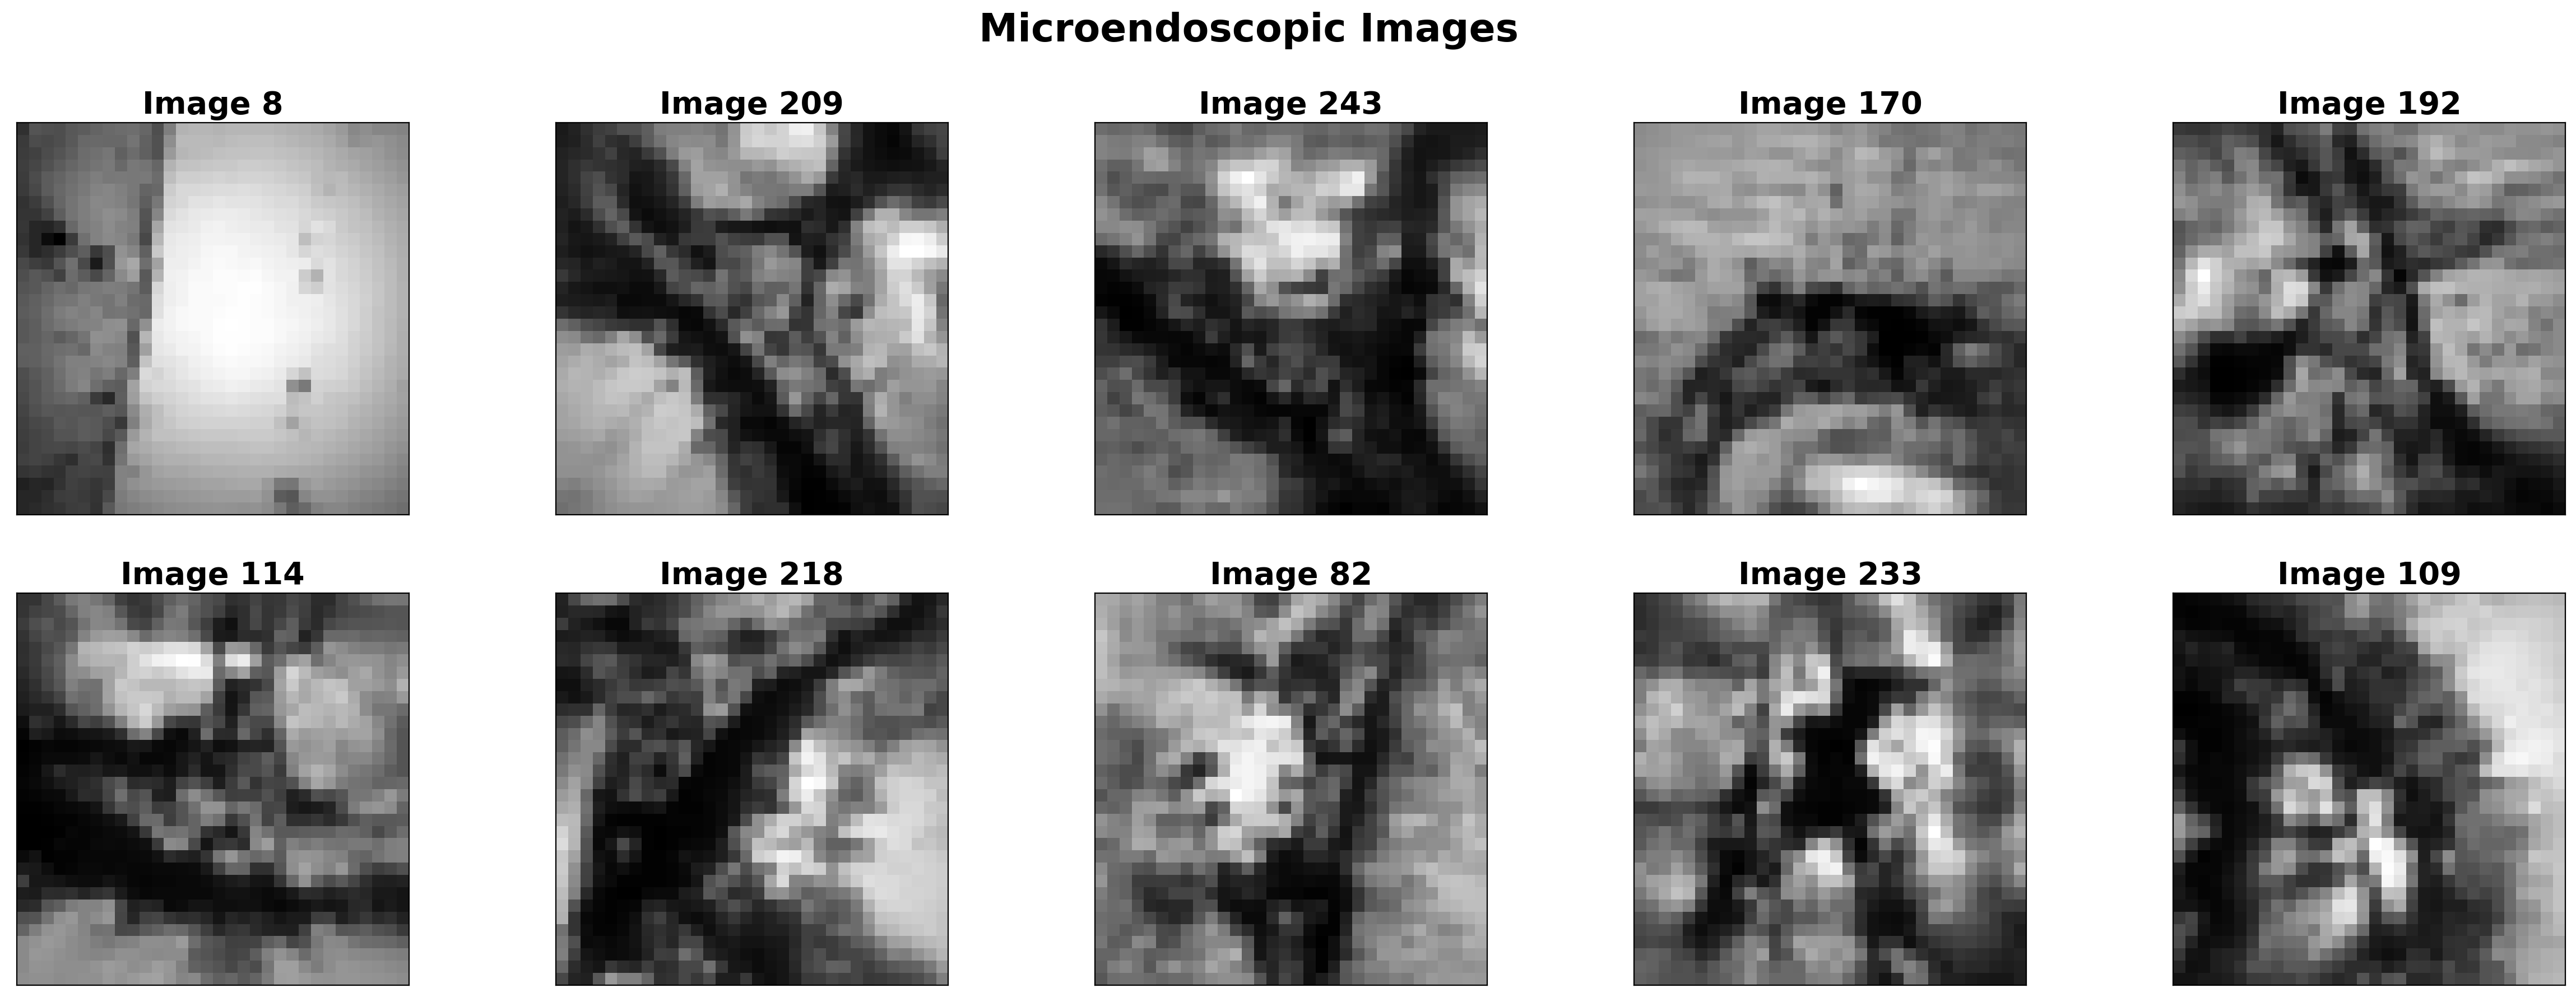

In [9]:
def microendoscopic_images(train_loader): # demonstrates the ground truth microendoscopic images 
  
  num_imgs = 10
    
  #obtain one batch of training images
  images, _, labels = next(iter(train_loader))
    
  # plot the images in the batch, along with the corresponding labels
  fig = plt.figure(figsize=(30, 10))

  # display num_imgs
  for idx in np.arange(num_imgs):
    ax = fig.add_subplot(2, int(num_imgs/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f'Image {labels[idx].numpy()}', fontsize=20, fontweight ='bold')
  plt.suptitle('Microendoscopic Images', fontsize=25, fontweight ='bold')
  plt.show()
    
microendoscopic_images(train_loader)

In [13]:
class Reshape_Concat_Adap(torch.autograd.Function):
    blocksize = 0

    def __init__(self, block_size):
        # super(Reshape_Concat_Adap, self).__init__()
        Reshape_Concat_Adap.blocksize = block_size

    @staticmethod
    def forward(ctx, input_, ):
        ctx.save_for_backward(input_)

        data = torch.clone(input_.data)
        b_ = data.shape[0]
        c_ = data.shape[1]
        w_ = data.shape[2]
        h_ = data.shape[3]

        output = torch.zeros((b_, int(c_ / Reshape_Concat_Adap.blocksize / Reshape_Concat_Adap.blocksize),
                              int(w_ * Reshape_Concat_Adap.blocksize), int(h_ * Reshape_Concat_Adap.blocksize))).cuda()

        for i in range(0, w_):
            for j in range(0, h_):
                data_temp = data[:, :, i, j]
                #data_temp = torch.zeros(data_t.shape).cuda() + data_t
                #data_temp = data_temp.contiguous()
                data_temp = data_temp.view((b_, int(c_ / Reshape_Concat_Adap.blocksize / Reshape_Concat_Adap.blocksize),
                                            Reshape_Concat_Adap.blocksize, Reshape_Concat_Adap.blocksize))
                # print data_temp.shape
                output[:, :, i * Reshape_Concat_Adap.blocksize:(i + 1) * Reshape_Concat_Adap.blocksize,
                j * Reshape_Concat_Adap.blocksize:(j + 1) * Reshape_Concat_Adap.blocksize] += data_temp

        return output

    @staticmethod
    def backward(ctx, grad_output):
        inp, = ctx.saved_tensors
        input_ = torch.clone(inp.data)
        grad_input = torch.clone(grad_output.data)

        b_ = input_.shape[0]
        c_ = input_.shape[1]
        w_ = input_.shape[2]
        h_ = input_.shape[3]

        output = torch.zeros((b_, c_, w_, h_)).cuda()
        output = output.view(b_, c_, w_, h_)
        for i in range(0, w_):
            for j in range(0, h_):
                data_temp = grad_input[:, :, i * Reshape_Concat_Adap.blocksize:(i + 1) * Reshape_Concat_Adap.blocksize,
                            j * Reshape_Concat_Adap.blocksize:(j + 1) * Reshape_Concat_Adap.blocksize]
                # data_temp = torch.zeros(data_t.shape).cuda() + data_t
                data_temp = data_temp.contiguous()
                data_temp = data_temp.view((b_, c_, 1, 1))
                output[:, :, i, j] += torch.squeeze(data_temp)

        return Variable(output)


def My_Reshape_Adap(input, blocksize):
    return Reshape_Concat_Adap(blocksize).apply(input)

# The residualblock for reconstruction network
class ResidualBlock(nn.Module):
    def __init__(self, channels, has_BN = False):
        super(ResidualBlock, self).__init__()
        
        self.has_BN = has_BN
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        if has_BN:
            self.bn1 = nn.BatchNorm2d(channels)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        if has_BN:
            self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        
        residual = self.conv1(x)
        if self.has_BN:
            residual = self.bn1(residual)
        residual = self.prelu(residual)
        residual = self.conv2(residual)
        if self.has_BN:
            residual = self.bn2(residual)

        return x + residual
    


In [40]:
import torch




model1 = nn.Sequential( nn.ConvTranspose2d(256, 1024, kernel_size=1, stride=1, padding=0), 
                        nn.ConvTranspose2d(1024, 128, 8), # input shp: [N, 256, 1, 1], output shp: [N, 128, 8, 8]
                        nn.ReLU(),
                        nn.ConvTranspose2d(128, 32, 3, stride=2, padding=1, output_padding=1), # input shp: [N, 128, 8, 8], output shp: [N, 32, 16, 16]
                        nn.ReLU(),
                        nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), # input shp: [N, 32, 16, 16], output shp: [N, 3, 32, 32]
                        nn.Sigmoid()
                     )

model2 = nn.Sequential(nn.ConvTranspose2d(256, 128, 8), # input shp: [N, 256, 1, 1], output shp: [N, 128, 8, 8]
                      nn.ReLU(),
                      nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # input shp: [N, 128, 8, 8], output shp: [N, 64, 16, 16]
                      nn.ReLU(),
                      nn.ConvTranspose2d(64, 16, 3, stride=2, padding=1, output_padding=1), # input shp: [N, 64, 16, 16], output shp: [N, 16, 32, 32]
                      nn.ReLU(),
                      nn.ConvTranspose2d(16, 3, 3, padding=1), # input shp: [N, 16, 32, 32], output shp: [N, 3, 32, 32]
                      nn.Sigmoid()
                     )

# img = torch.rand(20, 256, 1, 1)

# recon = model(img)

#print(recon.shape)

In [26]:
class BaseDecoder(nn.Module):
    def __init__(self, dim_size=32, subrate=0.25):
        super().__init__()
        self.dim_size = dim_size
        self.subrate = subrate

        self.upsampling = nn.ConvTranspose2d(int(np.round(dim_size*dim_size*subrate)), dim_size*dim_size, kernel_size=1, stride=1, padding=0)

        self.decode = nn.Sequential(
                                    nn.BatchNorm2d(1),
                                    nn.Conv2d(1, 64, kernel_size=9, padding=4),
                                    nn.PReLU(),
                                    nn.Conv2d(64, 32, kernel_size=1, padding=0),
                                    nn.PReLU(),
                                    nn.Conv2d(32, 1, kernel_size=5, padding=2),
                                    nn.PReLU()
                                    )  
        
#         # reconstruction network
#         self.block1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, padding=3),
#                                     nn.PReLU()
#                                    )
#         self.block2 = ResidualBlock(64, has_BN=True)
#         self.block3 = ResidualBlock(64, has_BN=True)
#         self.block4 = ResidualBlock(64, has_BN=True)
#         self.block5 = ResidualBlock(64, has_BN=True)
#         self.block6 = ResidualBlock(64, has_BN=True)
        
#         self.block7 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=3, padding=1),
#                                     nn.PReLU()
#                                     )
#         self.block8 = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def compute_l1_loss(self, w):
        return torch.abs(w).sum()
    
    def forward(self, x):
        x = self.upsampling(x)
       # x = My_Reshape_Adap(x, 32)
        x = x.view(x.shape[0],1,32,32)
#         block1 = self.block1(x)
#         block2 = self.block2(block1)
#         block3 = self.block3(block2)
#         block4 = self.block4(block3)
#         block5 = self.block5(block4)
#         block6 = self.block6(block5)
#         block7 = self.block7(block6)
#         block8 = self.block8(block1 + block7)


        return self.decode(x)    #block8
    
    
    
    
    
    
    
       # nn.PReLU(),
       # nn.PixelShuffle(32)
#         nn.BatchNorm2d(dim_size*dim_size),
#         nn.ReLU(inplace=True)
#         nn.Conv2d(dim_size*dim_size, 64, kernel_size=5, padding=2),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(64, 64, kernel_size=3, padding=1),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(64, 32, kernel_size=3, padding=1),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(32, upscale_factor ** 2, kernel_size=3, padding=1),
       #nn.PixelShuffle(upscale_factor)
#         nn.PReLU(),
#         nn.ConvTranspose2d( dim_size*dim_size, 256, kernel_size=1, stride=1, padding=5),
#         nn.PReLU(),
#         nn.ConvTranspose2d( 256, 64, kernel_size=1, stride=1, padding=5),
#         nn.PReLU(),
#         nn.ConvTranspose2d(64, 16, kernel_size=1, stride=1, padding=5),
#         nn.PReLU(),
#         nn.ConvTranspose2d(16, 1, kernel_size=2, stride=1, padding=1),
#         nn.PReLU()     

    
#     self.decode = nn.Sequential(
#         nn.ConvTranspose2d(dim_size*dim_size, dim_size,kernel_size=3, stride=1, padding=1),
#         nn.ReLU(),
#         nn.ConvTranspose2d(dim_size*dim_size, dim_size,kernel_size=3, stride=1, padding=1),
#         nn.ReLU(),
#         nn.ConvTranspose2d(dim_size*dim_size, dim_size,kernel_size=3, stride=1, padding=1),
#         nn.ReLU()
#     )   




# def SuperResolutionNetNew(upscale_factor):
#     return nn.Sequential(
#         nn.Conv2d(1, 64, kernel_size=5, padding=2),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(64, 64, kernel_size=3, padding=1),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(64, 32, kernel_size=3, padding=1),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(32, upscale_factor ** 2, kernel_size=3, padding=1),
#         Rearrange('b (h2 w2) h w -> b (h h2) (w w2)', h2=upscale_factor, w2=upscale_factor),
#     )


#             nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(ndf * 8),
#             nn.LeakyReLU(0.2, inplace=True),



#             nn.Conv2d(1, 64, 11, stride=1, padding=5, dilation=1),
#             nn.BatchNorm2d(64),
#             nn.LeakyReLU(),



#     def __init__(self,channels,cr):
#         super(CSNET,self).__init__()

#         self.channels = channels
#         self.fcr = 153
#         self.base = 1

#         self.sample = nn.Conv2d(self.channels,self.fcr,kernel_size=32,padding=0,stride=32,bias=False)
#         self.initial = nn.Conv2d(self.fcr,3072,kernel_size=1,padding=0,stride=1,bias=False)
#         self.pixelshuffle = nn.PixelShuffle(32)
#         self.conv1 = nn.Conv2d(self.channels,self.base,kernel_size=3,padding=1,stride=1,bias=False)
#         self.conv2 = nn.Conv2d(self.base,self.base,kernel_size=3,padding=1,stride=1,bias=False)
#         self.conv3 = nn.Conv2d(self.base,self.channels,kernel_size=3,padding=1,stride=1,bias=False)
#         self.relu = nn.ReLU(inplace=True)

#     def forward(self,input,batch_size,ngpu):
#         output = self.sample(input)
#         output = self.initial(output)
#         output = self.pixelshuffle(output)
#         output = self.relu(self.conv1(output))
#         output = self.relu(self.conv2(output))
#         output = self.relu(self.conv2(output))
#         output = self.relu(self.conv2(output))
#         output = self.conv3(output)
        
#             nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
#             nn.LeakyReLU(0.2, inplace=True),
#             # state size. (ndf) x 32 x 32
#             nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(ndf * 2),
#             nn.LeakyReLU(0.2, inplace=True),
#             # state size. (ndf*2) x 16 x 16
#             nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(ndf * 4),
#             nn.LeakyReLU(0.2, inplace=True),
#             # state size. (ndf*4) x 8 x 8
#             nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(ndf * 8),
#             nn.LeakyReLU(0.2, inplace=True),
#             # state size. (ndf*8) x 4 x 4
#             nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
#             nn.Sigmoid()
            
            
        

In [15]:
def save_model(epochs, model, optimizer, criterion):
    """
    Function to save the trained model to disk.
    """
    torch.save({
                'epoch': epochs,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': criterion,
                }, './model.pth')

In [15]:
class SSIMLoss(SSIM):
    def forward(self, x, y):
        return 1. - super().forward(x, y)

class PSNRLoss(PSNR):
    def forward(self, x, y):
        return - super().forward(x, y)

def psnr_loss(x, y, **kwargs):
  return - psnr(x, y)

def ssim_loss(x, y, **kwargs):
  return 1 - ssim(x, y)

criterions_dict = {"ssim": SSIMLoss, "mse": nn.MSELoss, "psnr": PSNRLoss}
metrics_dict = {"ssim": SSIM().forward, "mse": nn.MSELoss().forward, "psnr": PSNR().forward}

In [16]:
def compare_images(ref_img, img):
    
  num_list = random.sample(range(len(ref_img)), 10)
  psnr = PeakSignalNoiseRatio()
  ssim = StructuralSimilarityIndexMeasure(data_range=1.0)
  f, axes = plt.subplots(2, 5, figsize=(30, 10))
  a = np.arange(0,10)

  for idx in range(5):
    axes[0,a[idx]].imshow(np.transpose(ref_img[num_list[idx]],(1,2,0)),cmap='gray')
    axes[0,a[idx]].set_title(f'Image {idx+1}', fontsize=15, fontweight ='bold')
    axes[1,a[idx]].imshow(np.transpose(img[num_list[idx]],(1,2,0)),cmap='gray') 
    axes[1,a[idx]].set_title("PSNR: {0:.2f}, SSIM: {1:.2f}".format(
    psnr(torch.unsqueeze(ref_img[num_list[idx]], axis=0), torch.unsqueeze(img[num_list[idx]], axis=0)), 
    ssim(torch.unsqueeze(ref_img[num_list[idx]], axis=0), torch.unsqueeze(img[num_list[idx]], axis=0))), 
    fontweight='bold')

  plt.suptitle('Inference Results of Test Images', fontsize=25, fontweight ='bold')
  plt.show()

In [17]:
def inference_results(outputs):
  for img, output in outputs:
    compare_images(img, output.detach().cpu())

In [19]:
CriterionType = Callable[[Tensor, Tensor], Tensor]

def evaluate(model: BaseDecoder, 
             data_loader: DataLoader, 
             device: torch.device,
             criterion: CriterionType, 
             optimizer: Optional[Optimizer] = None,
             num_epochs: int = 1,
             metrics_fn: Optional[Dict[str, CriterionType]] = None,
             train_mode: bool = False) -> List[Any]:
             
    """This function starts training/testing with the given 
    parameters.

    Parameters
    ----------
    model : DCMN
      The (encoder/decoder) network that training is made.
    data_loader: DataLoader
      Contains test/train/val data.
    device: torch.device
      Indicates the runtime type (cuda vs. CPU).
    criterion: Callable[[Tensor, Tensor], Tensor]
      A criterion function that measures loss between ground truth and output.
    optimizer: Optional[Optimizer] 
      The optimizer that training is made.
    num_epochs: int
      Number of epochs.
    metrics_fn: Optional[Dict[str, CriterionType]]
      List of metric functions.
    train_mode: bool
      Indicates the current mode of the evaluation (i.e. test or train) by 
      default True.

    Returns
    -------
    List[Any]
      Resultant information (output image, epoch number, metrics etc.).

    """
    model.train(mode=train_mode)
    outputs = []
         
    for epoch in range(num_epochs):
      with tqdm(data_loader, unit="batch") as tepoch:
        for image, cs_vec, target in tepoch:
          tepoch.set_description(f"Epoch {epoch}")

        # for (image, _) in data_loader:
          img = image.to(device) #reshape((image.shape[0],1024,1,1)).to(device)
            
          cs_vec = cs_vec.to(device)

          # forward pass
          recon = model(cs_vec)
      
          # calculate the loss
          loss = criterion(recon, img)
            
#           # Compute L1 loss component
#           l1_weight = 1.0
#           l1_parameters = []
#           for parameter in model.parameters():
#               l1_parameters.append(parameter.view(-1))
#           l1 = l1_weight * model.compute_l1_loss(torch.cat(l1_parameters))

#           # Add L1 loss component
#           loss += l1
        
          if train_mode:
            optimizer.zero_grad()
            
            # backpropagation
            loss.backward()
            
            # update the optimizer parameters
            optimizer.step()
            tepoch.set_postfix(loss=loss.item())
            
          else:
            outputs.append((image, recon)) 
    
    return outputs

Epoch 0: 100%|██████████| 2/2 [00:00<00:00,  5.60batch/s]


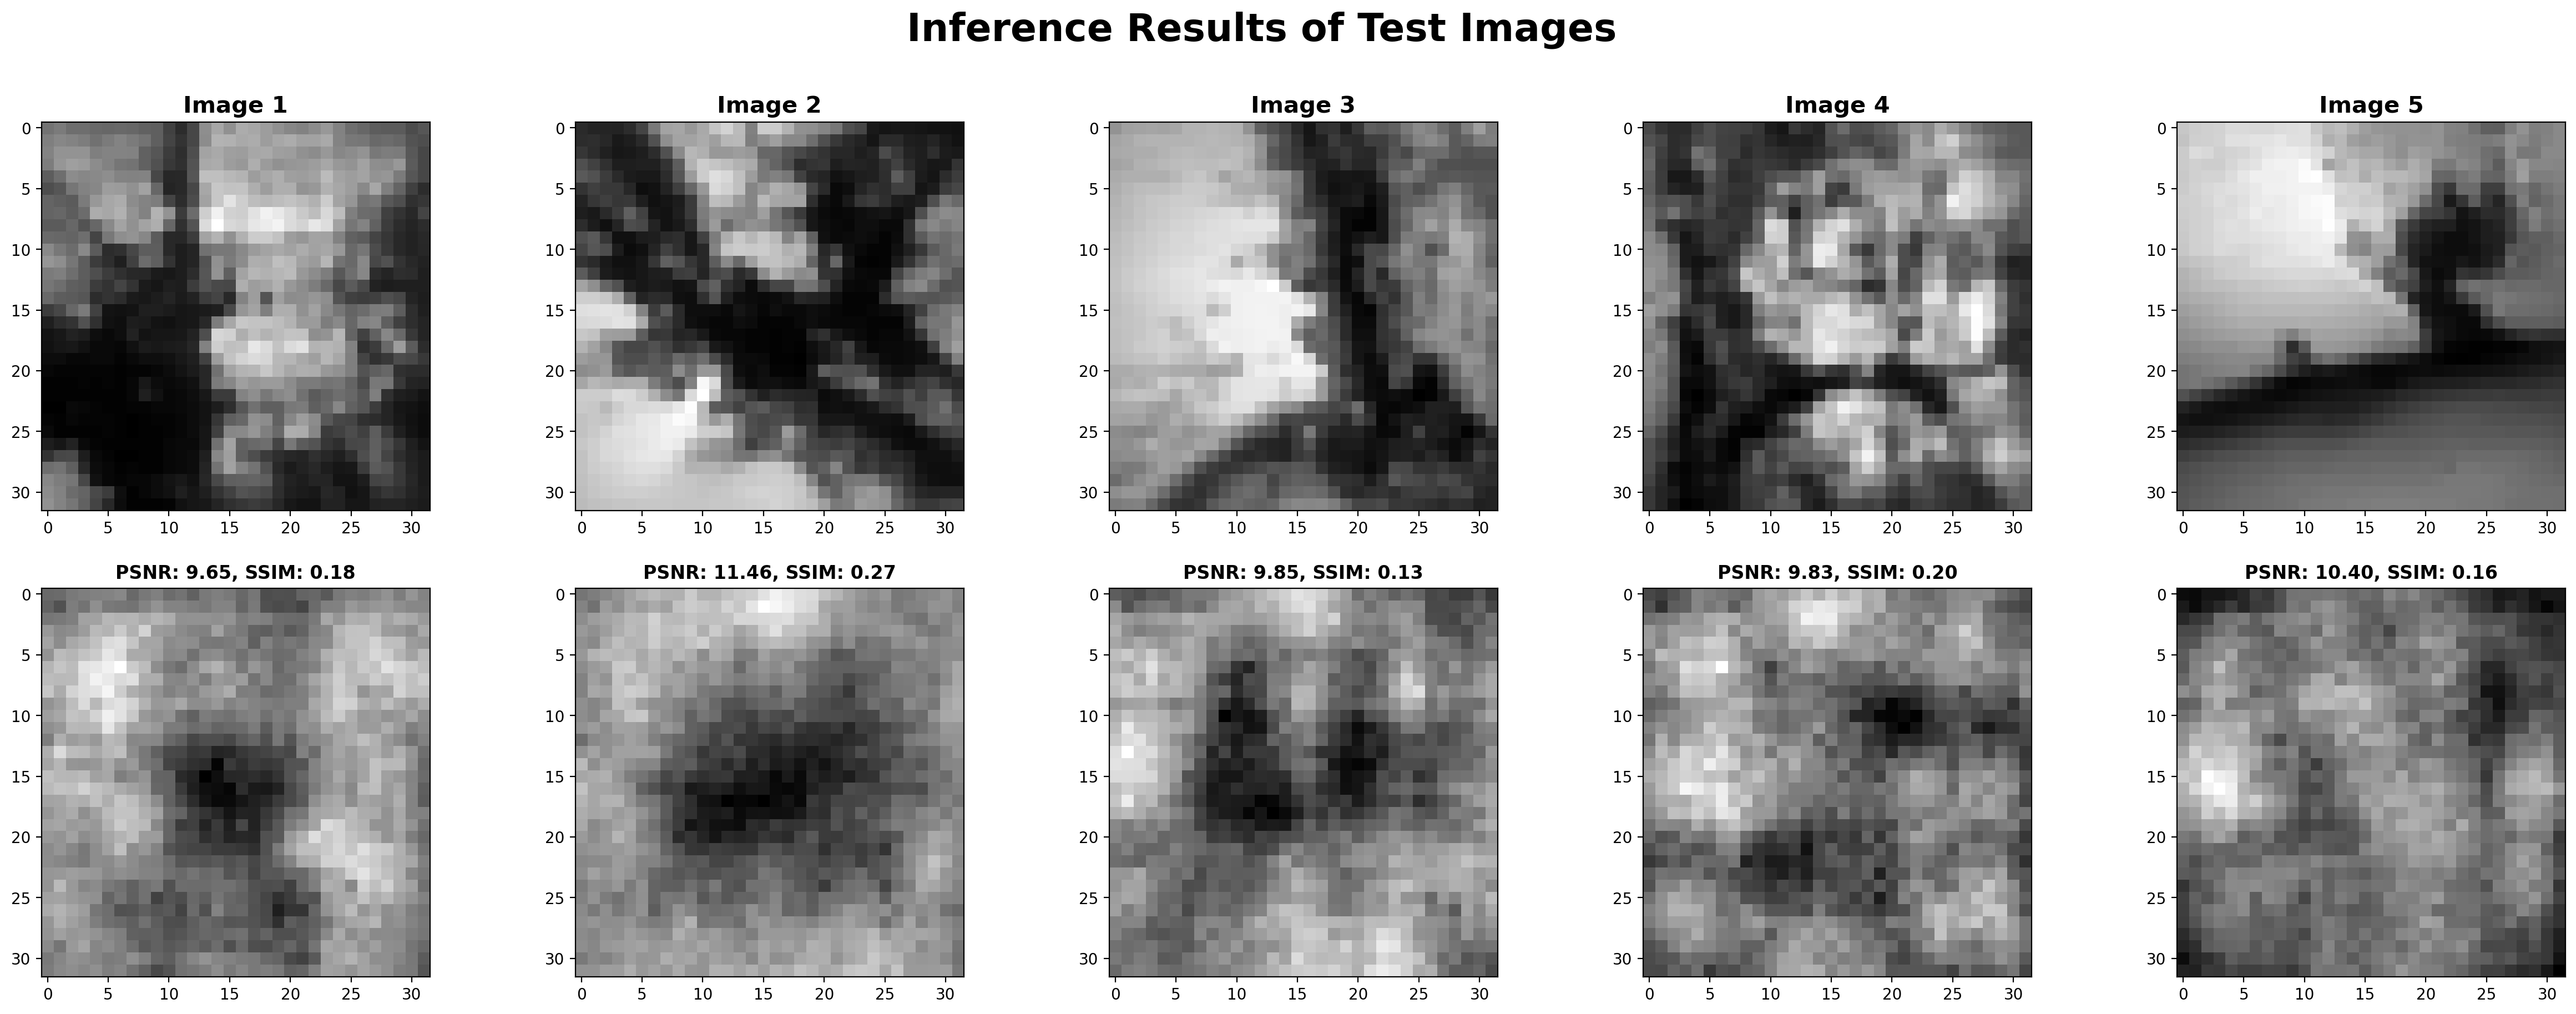

In [53]:
def main():

  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  num_epochs = 500

  model = BaseDecoder().to(device)
  criterion = criterions_dict["mse"]().to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay= 1e-6)
  metrics_fn = metrics_dict


  evaluate(
    model, train_loader, device, criterion, 
    optimizer, num_epochs, metrics_fn, True
  )
  
  # save the trained model weights
  #save_model(num_epochs, model, optimizer, criterion)


  # results of test data

  test_outputs = evaluate(
     model=model, data_loader=test_loader, device=device, 
    criterion=criterion, metrics_fn=metrics_fn
  )
    
#   train_outputs = evaluate(
#      model=model, data_loader=train_loader, device=device, 
#     criterion=criterion, metrics_fn=metrics_fn
#   )
   
  inference_results(test_outputs[:1])

if __name__ == "__main__":
    main()

<generator object Module.parameters at 0x7a7940b76150>